<i>Based on code by Alexandre Nesovic

<h2>Exercise 4.4, S&P 500 index</h2>


In this example, we use the S&P500 index and along with its constituent stocks. 
1. We choose a time period of interest.
2. We download the data.
3. We cluster the stocks based on the average return and volatility. 
4. We apply Principal component analysis and compare the first principal component PC1 with the S&P500 index. We look how well PC1 tracks the index.
5. Based on PC1, we try to form a winning portfolio. 

In [130]:
! pip install yfinance

Defaulting to user installation because normal site-packages is not writeable


In [131]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

Choose a time period. Download S&P500 index (SPY) from Yahoo Finance

In [132]:
# repeat the exercise with different time periods
start_date = '2023-09-05'
end_date = '2024-03-05'

In [133]:
prices_SPY = yf.download(['SPY'], start=start_date, end=end_date, auto_adjust=False)['Adj Close']

[*********************100%***********************]  1 of 1 completed


Download S&P500 tickers from Wikipedia to 'tables'. Then, download the corresponding stock adjusted closing prices from Yahoo Finance. 


In [134]:
url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
tables = pd.read_html(url)
sp500_table = tables[0]
sp500_tickers = sp500_table['Symbol'].tolist()

print(sp500_tickers)

['MMM', 'AOS', 'ABT', 'ABBV', 'ACN', 'ADBE', 'AMD', 'AES', 'AFL', 'A', 'APD', 'ABNB', 'AKAM', 'ALB', 'ARE', 'ALGN', 'ALLE', 'LNT', 'ALL', 'GOOGL', 'GOOG', 'MO', 'AMZN', 'AMCR', 'AEE', 'AEP', 'AXP', 'AIG', 'AMT', 'AWK', 'AMP', 'AME', 'AMGN', 'APH', 'ADI', 'ANSS', 'AON', 'APA', 'APO', 'AAPL', 'AMAT', 'APTV', 'ACGL', 'ADM', 'ANET', 'AJG', 'AIZ', 'T', 'ATO', 'ADSK', 'ADP', 'AZO', 'AVB', 'AVY', 'AXON', 'BKR', 'BALL', 'BAC', 'BAX', 'BDX', 'BRK.B', 'BBY', 'TECH', 'BIIB', 'BLK', 'BX', 'BK', 'BA', 'BKNG', 'BSX', 'BMY', 'AVGO', 'BR', 'BRO', 'BF.B', 'BLDR', 'BG', 'BXP', 'CHRW', 'CDNS', 'CZR', 'CPT', 'CPB', 'COF', 'CAH', 'KMX', 'CCL', 'CARR', 'CAT', 'CBOE', 'CBRE', 'CDW', 'COR', 'CNC', 'CNP', 'CF', 'CRL', 'SCHW', 'CHTR', 'CVX', 'CMG', 'CB', 'CHD', 'CI', 'CINF', 'CTAS', 'CSCO', 'C', 'CFG', 'CLX', 'CME', 'CMS', 'KO', 'CTSH', 'CL', 'CMCSA', 'CAG', 'COP', 'ED', 'STZ', 'CEG', 'COO', 'CPRT', 'GLW', 'CPAY', 'CTVA', 'CSGP', 'COST', 'CTRA', 'CRWD', 'CCI', 'CSX', 'CMI', 'CVS', 'DHR', 'DRI', 'DVA', 'DAY', 'D

In [135]:
prices = yf.download(sp500_tickers, start=start_date, end=end_date, auto_adjust=False)['Adj Close'] 

[*********************100%***********************]  503 of 503 completed

5 Failed downloads:
['BRK.B']: YFTzMissingError('possibly delisted; no timezone found')
['BF.B']: YFPricesMissingError('possibly delisted; no price data found  (1d 2023-09-05 -> 2024-03-05)')
['SW', 'GEV', 'SOLV']: YFPricesMissingError('possibly delisted; no price data found  (1d 2023-09-05 -> 2024-03-05) (Yahoo error = "Data doesn\'t exist for startDate = 1693886400, endDate = 1709614800")')


Compute the log-returns rs.
Then, compute the return (the percentage change), the average returns and the volatilities.


In [136]:
# Calculate daily log returns
rs = np.log((prices) / prices.shift(1))
rs = rs.fillna(0)

# Calculate daily percentage returns 
returns = prices.pct_change()

# Calculate annualized metrics based on 7 month period (147 trading days)
trading_days = 147
average_returns = rs.mean() * trading_days
volatility = rs.std() * np.sqrt(trading_days)
volatility.head()

/tmp/ipykernel_9507/3361682277.py:6: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = prices.pct_change()


Ticker
A       0.213752
AAPL    0.142100
ABBV    0.123231
ABNB    0.272678
ABT     0.137060
dtype: float64

In [137]:
rv = np.column_stack((average_returns, volatility))
rv= np.nan_to_num(rv)

<h4>KMeans clustering </h4>

From sklearn, import KMeans. Then, Compute k-means clustering for 'rv'. The number of clusters can be 4. the cluster centers can be extracted via  '.cluster_centers_'

In [138]:
from sklearn.cluster import KMeans
 
km_res = KMeans(n_clusters=4)
clusters = km_res.fit_predict(rv)
 

Draw a scatter plot of the average_return and volatility. Plot also the cluster centroids.

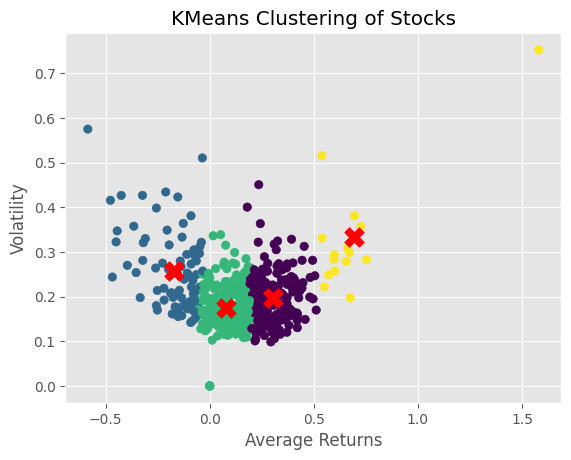

In [139]:
#scatter plot here

plt.scatter(average_returns, volatility, c=clusters, cmap='viridis')
plt.scatter(km_res.cluster_centers_[:, 0], km_res.cluster_centers_[:, 1], s=200, c='red', marker='X')
plt.xlabel('Average Returns')
plt.ylabel('Volatility')
plt.title('KMeans Clustering of Stocks')
plt.show()


Define and print the labels of each point

In [140]:
labels = clusters
print(labels)

[0 1 0 2 0 2 0 2 2 1 2 0 2 2 1 2 0 0 2 2 1 1 0 2 0 2 3 2 2 0 2 0 0 2 2 0 1
 1 0 0 1 2 2 2 3 2 1 0 0 0 1 0 0 2 2 1 2 2 1 1 0 2 1 0 0 1 2 2 2 0 0 2 0 2
 0 2 0 0 0 2 2 2 0 2 3 2 2 2 1 1 0 2 0 2 1 2 0 0 2 0 2 0 2 1 0 0 2 2 0 1 0
 0 3 1 2 0 0 1 2 2 2 1 1 2 2 3 1 1 1 3 3 0 0 2 0 2 0 0 0 1 2 2 2 2 2 2 0 1
 0 2 2 0 2 0 2 2 1 2 2 2 1 1 0 0 2 1 0 2 2 0 2 2 2 1 1 2 0 0 2 0 0 1 2 2 2
 2 0 0 0 0 1 1 2 1 2 2 0 0 0 0 2 2 2 2 2 2 0 1 2 2 2 2 0 0 0 1 1 0 2 2 1 0
 0 0 2 2 2 2 1 2 0 1 0 1 0 0 0 2 2 2 1 0 0 2 2 2 2 0 0 0 0 2 2 2 2 0 2 2 2
 0 0 2 1 0 2 2 2 3 0 2 2 1 2 2 1 0 0 0 2 0 0 0 2 0 2 2 2 0 2 2 2 2 2 0 2 1
 0 0 2 2 0 2 2 2 2 3 2 0 1 1 0 2 1 2 1 0 1 0 0 2 1 2 2 0 0 2 1 2 0 0 2 2 1
 1 0 2 2 2 0 0 0 0 2 2 3 0 0 0 0 2 2 0 2 1 1 2 2 1 0 1 1 2 0 2 2 2 1 2 2 0
 0 0 0 2 3 2 0 2 2 1 2 2 2 2 2 0 0 2 1 0 0 2 2 2 2 0 0 1 0 2 0 0 2 1 1 2 2
 0 1 1 3 2 0 2 2 0 2 2 2 0 2 0 2 2 2 2 0 0 2 0 2 0 2 1 2 2 0 0 2 1 2 0 1 0
 2 2 2 0 2 1 2 0 2 2 2 2 1 3 2 0 0 2 0 1 0 0 2 2 2 2 0 2 1 0 3 2 0 0 0 0 1
 1 2 0 2 2 0 0 2 2 0 3 1 

In [141]:
ar_clusters = np.column_stack((average_returns, 
                               volatility, labels))

In [142]:
df = pd.DataFrame(ar_clusters)
df.columns = ['average_returns', 'volatility', 'cluster_label']
df.dropna(axis=0, how='any', subset=None, inplace=False)
df['cluster_label'] = df['cluster_label'].astype(int)
df.dtypes

average_returns    float64
volatility         float64
cluster_label        int64
dtype: object

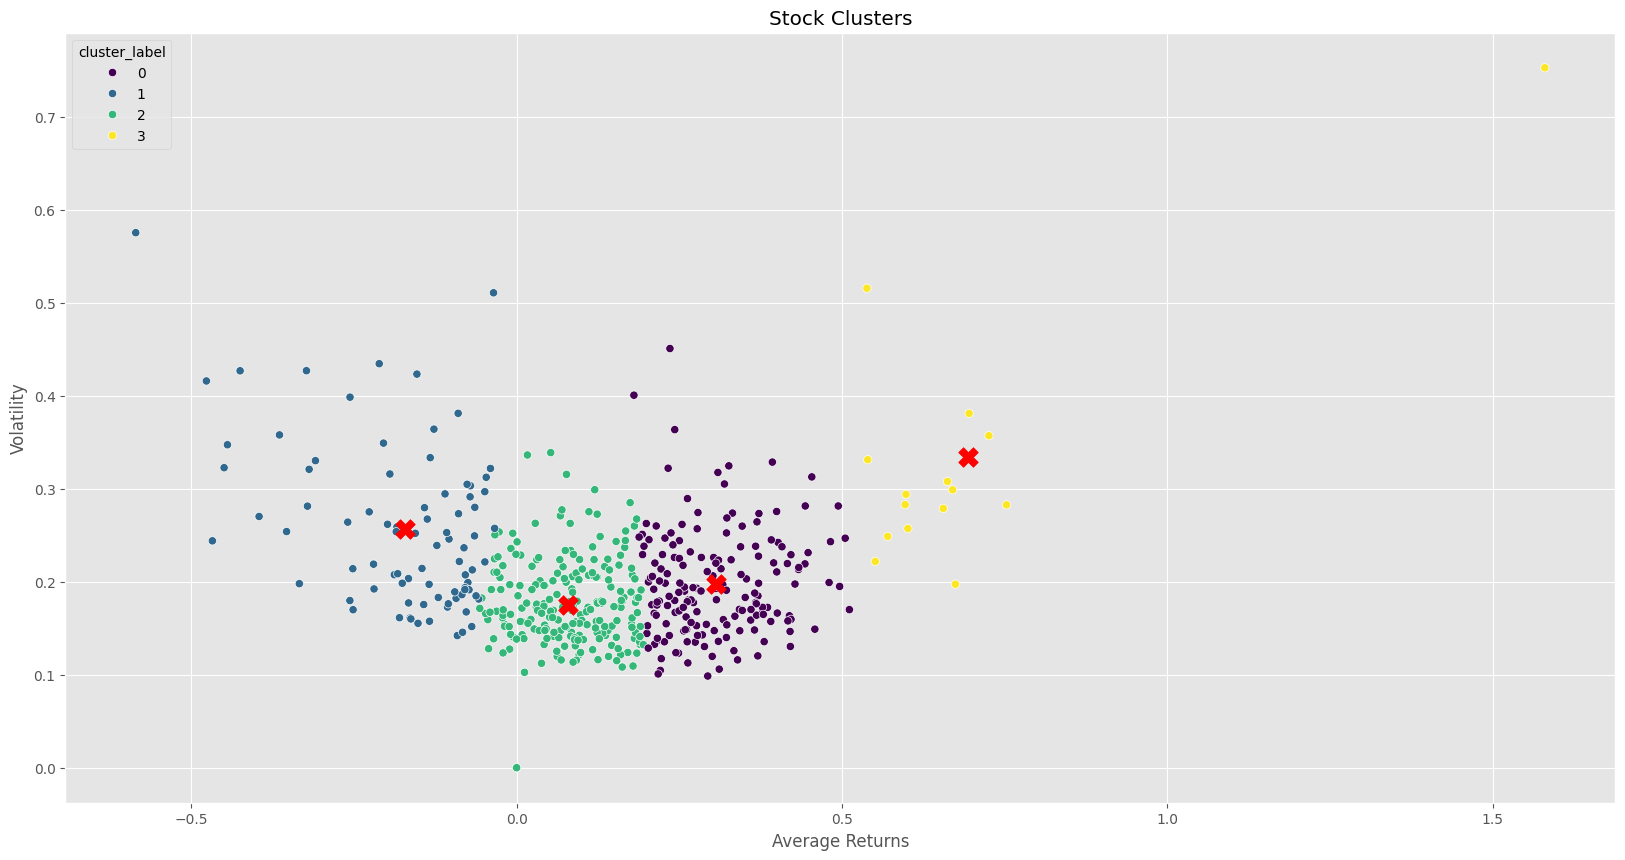

In [143]:
plt.figure(figsize=(20, 10))
ax = sns.scatterplot(data=df, x='average_returns', y='volatility', hue='cluster_label', palette='viridis')

plt.scatter(km_res.cluster_centers_[:, 0], km_res.cluster_centers_[:, 1], s=200, c='red', marker='X')
plt.xlabel('Average Returns')
plt.ylabel('Volatility') 
plt.title('Stock Clusters')
plt.show()
                     
 

We remove the outliers.

In [144]:
#Removing outliers
no_outlier= pd.DataFrame(df).apply(pd.to_numeric, errors='ignore') #in case not all columns are numeric
df_no_outlier = no_outlier.mask((no_outlier- no_outlier.mean()).abs() > 2 * no_outlier.std()).dropna()
df_no_outlier.columns = ['Average returns', 'Volatility', 'Cluster label']

/tmp/ipykernel_9507/1275208824.py:2: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  no_outlier= pd.DataFrame(df).apply(pd.to_numeric, errors='ignore') #in case not all columns are numeric


Q: Above, we filtered out outliers from the DataFrame no_outlier based on a rule: ...


In [145]:
df_average_returns = pd.DataFrame(average_returns)
df_average_returns.reset_index(level=0, inplace=True)

In [146]:
#We need to rename the second column (called "0") in order to have a 
#common column to perform the merge on.
 
df_average_returns.columns = ['index', 'average_returns']
 
#Let's merge. 
 
with_index = pd.merge(df_average_returns, df)
with_index.head()

,index,average_returns,volatility,cluster_label
0,A,0.221931,0.213752,0
1,AAPL,-0.091134,0.142100,1
2,ABBV,0.248853,0.123231,0
3,ABNB,0.123830,0.272678,2
4,ABT,0.216658,0.137060,0


Apply the Elbow method to select the optimal number of clusters. Plot the corresponding picture. 
(This method has been applied in a previous exercise.)

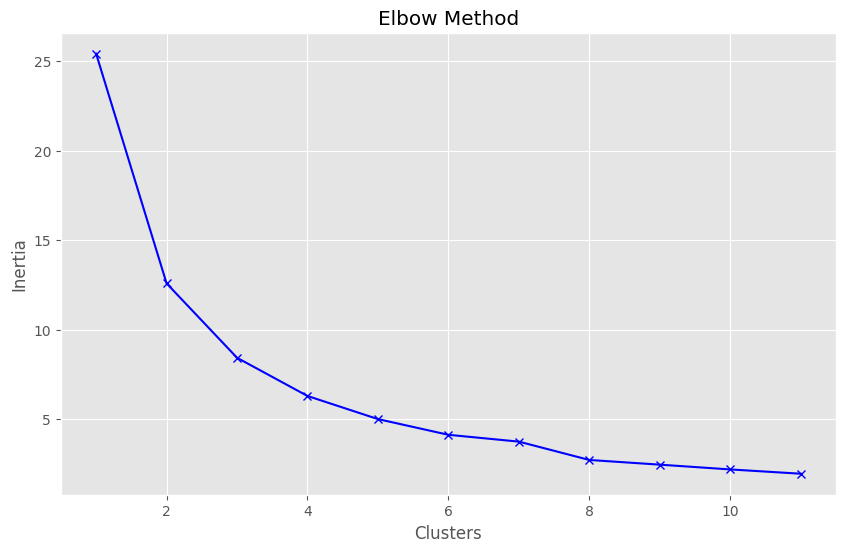

In [147]:
# Elbow method and figure here
# Calculate inertia for different numbers of clusters
inertia = []
K = range(1, 12)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=1)
    kmeans.fit(df[['average_returns', 'volatility']])
    inertia.append(kmeans.inertia_)

# Plot elbow curve
plt.figure(figsize=(10, 6))
plt.plot(K, inertia, 'bx-')
plt.xlabel('Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.grid(True)
plt.show()


Present the size of each cluster as bars. You can use countplot in seaborn.

/tmp/ipykernel_9507/2952604712.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = 'cluster_label', data = with_index,


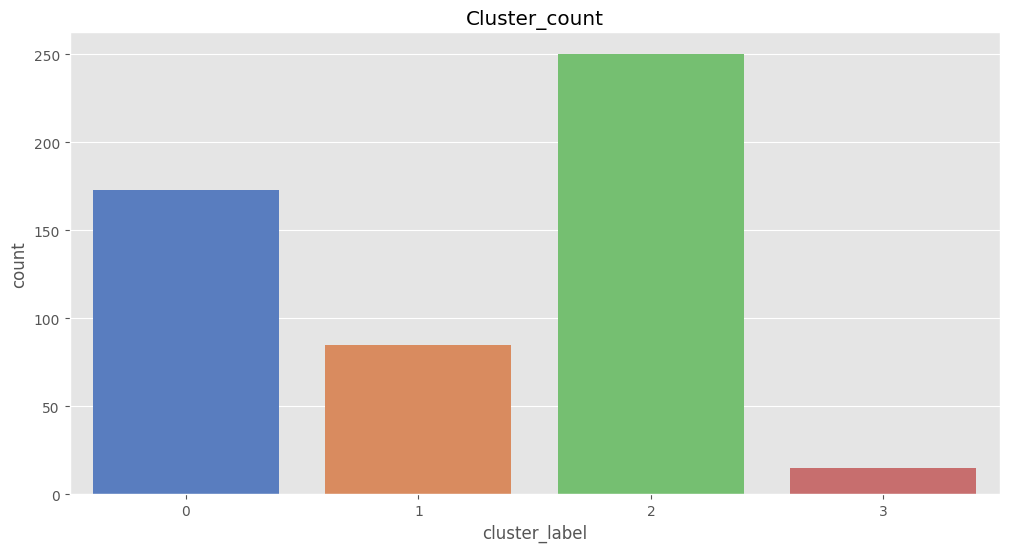

<Figure size 640x480 with 0 Axes>

In [148]:
plt.style.use('ggplot')
plt.figure(figsize=(12,6))
sns.countplot(x = 'cluster_label', data = with_index, 
              palette = 'muted', edgecolor='none', legend=False)
plt.title('Cluster_count')
plt.show()
plt.savefig('cluster_count.png', dpi=300)

In [149]:
count_clusters = with_index["cluster_label"].value_counts().to_frame()
count_clusters.reset_index(level=0, inplace=True)
count_clusters.columns = ["cluster_label","nb"]

In [150]:
df_descriptive_stats = with_index.iloc[:, 1:4]
df_groupby_cluster = df_descriptive_stats.groupby(["cluster_label"], 
                                  as_index=False).mean()

Present the average return by clusters using sns.barplot.

<Axes: xlabel='cluster_label', ylabel='average_returns'>

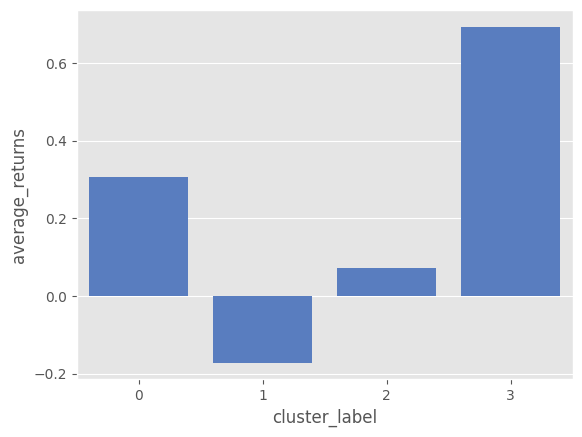

In [151]:
sns.barplot(x="cluster_label", y="average_returns", data=df_groupby_cluster, palette='muted', hue=0, legend=False)

<Axes: xlabel='cluster_label', ylabel='volatility'>

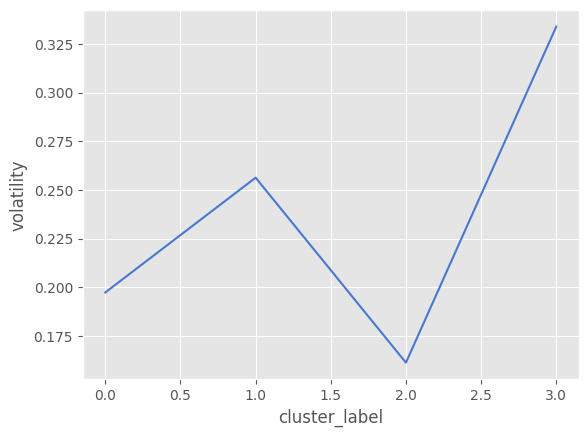

In [152]:
sns.lineplot(x="cluster_label", y="volatility", data=df_groupby_cluster, palette='muted', hue=0, legend=False)

Based on the bar charts above, how would you comment on the clustering? Is this a good clustering from the point of view of an investor? 

<h4>Principal component analysis

In [153]:
# Import the PCA algorithm from sklearn

from sklearn.decomposition import PCA

#  first principal component of the returns rs.
pca = PCA(n_components=1)
pca.fit(rs)

PCA(n_components=1)

<Axes: title={'center': 'First Principal Component of the S&P500'}, xlabel='Ticker'>

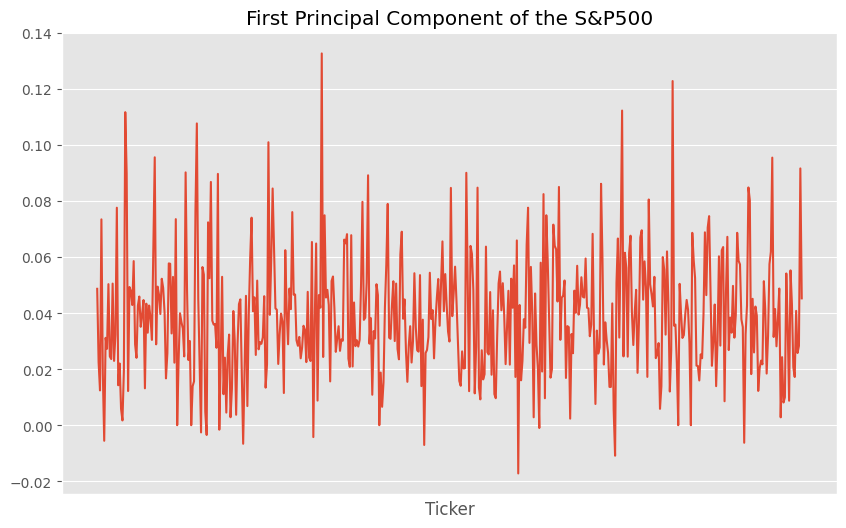

In [154]:
pc1 = pd.Series(index=rs.columns, data=pca.components_[0])

pc1.plot(figsize=(10,6), xticks=[], grid=True, title='First Principal Component of the S&P500')


<Axes: xlabel='Date'>

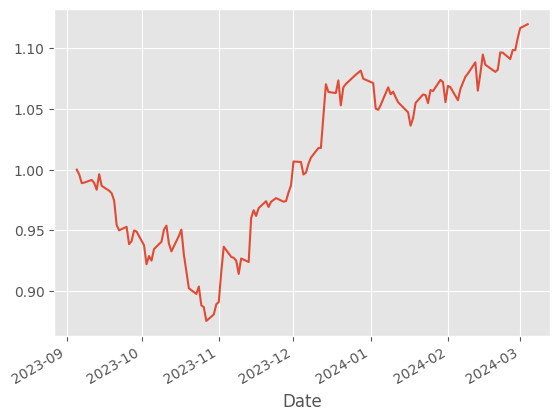

In [155]:
weights = abs(pc1)/sum(abs(pc1))
myrs = (weights*rs).sum(1)
myrs.cumsum().apply(np.exp).plot()

Compute the log-returns of the S&P 500 index closing prices. Form a dataframe rs_df with 2 columns: our weighted PCA portfolio 'myrs' and the S&P 500 index adjclosing prices. Name these columns "PCA Portfolio" and "S&P500". Plot the returns of "PCA Portfolio" and "S&P500".  (not the log-returns)  (code snippet in the end of the exercise)

In [156]:
rs_df = pd.concat([myrs, prices_SPY.apply(np.log).diff(1)], axis=1)
rs_df.columns = ["PCA Portfolio", "S&P500"]



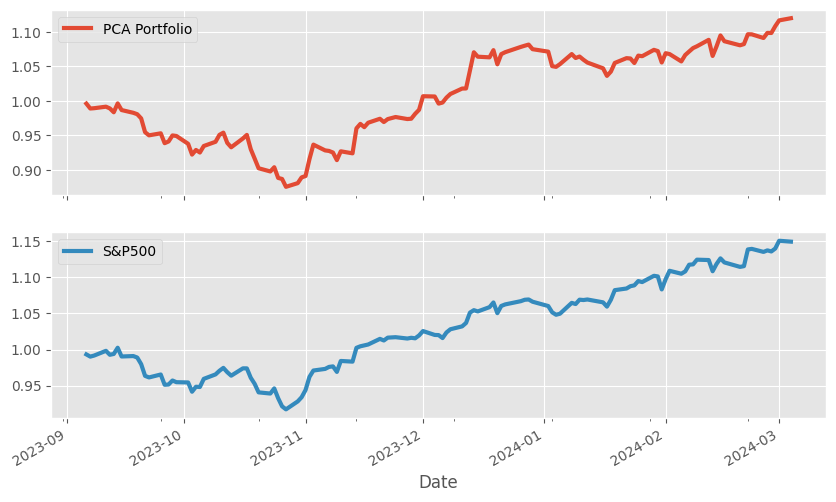

In [157]:
# plot here
rs_df.dropna().cumsum().apply(np.exp).plot(subplots=True, figsize=(10,6), grid=True, linewidth=3)
plt.show()

<Axes: xlabel='Date'>

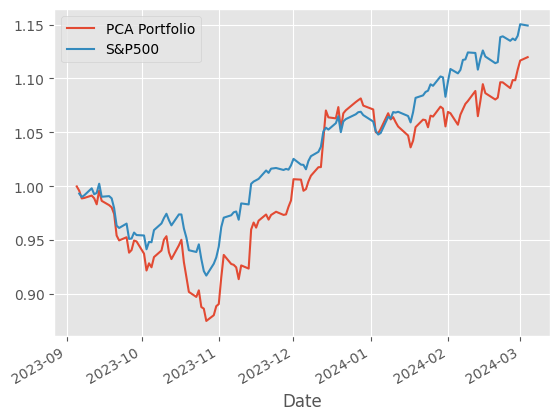

In [158]:
rs_df.cumsum().apply(np.exp).plot()

Using PCA, we can cluster together businesses that were most/least affected during the time period considered. 
1. Present with bars the 10 stocks that were the most affected 
2. Present with bars the 10 stocks that were the least affected

You can use pandas.dataframe.nsmallest and nlargest. (code snippet in the end of the exercise)


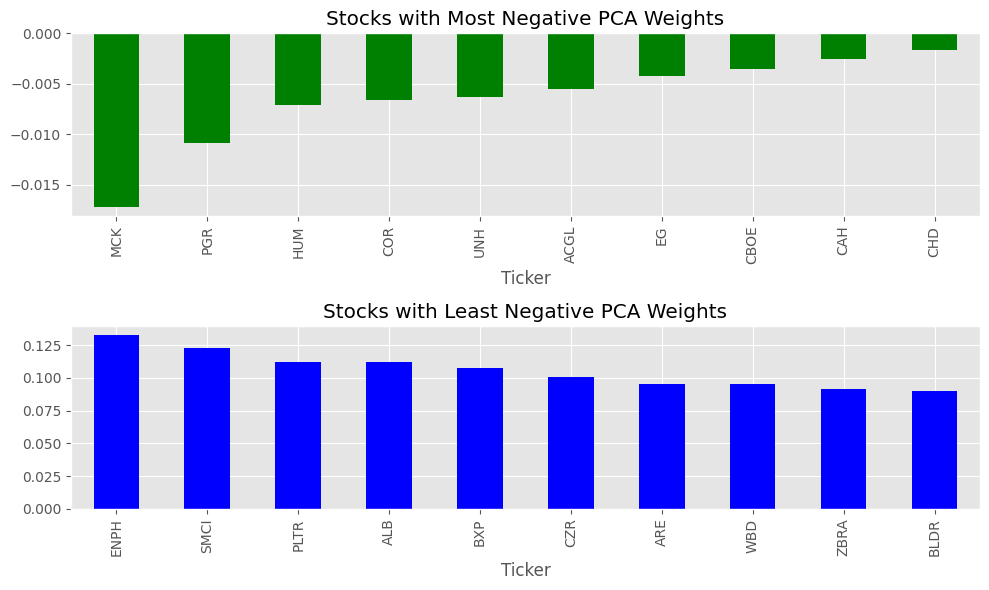

In [159]:
fig, ax = plt.subplots(2,1, figsize=(10,6))
pc1.nsmallest(10).plot.bar(ax=ax[0], color='green', grid=True, title='Stocks with Most Negative PCA Weights')
pc1.nlargest(10).plot.bar(ax=ax[1], color='blue', grid=True, title='Stocks with Least Negative PCA Weights')

plt.tight_layout()
plt.savefig('tmp.png')

Q: Analyze the results. Can you say anything about the industries in relation to the time? Why do some periods of time show only one blue bar or no bars at all?

In [160]:
pc1.nsmallest(50)

Ticker
MCK     -0.017220
PGR     -0.010887
HUM     -0.007057
COR     -0.006625
UNH     -0.006268
ACGL    -0.005559
EG      -0.004237
CBOE    -0.003490
CAH     -0.002577
CHD     -0.001605
MOH     -0.001003
BF.B     0.000000
BRK.B    0.000000
GEV      0.000000
SOLV     0.000000
SW       0.000000
AJG      0.001698
NOC      0.002342
WM       0.002812
MMC      0.002823
CME      0.002843
CNC      0.003727
CL       0.004501
CB       0.004850
PG       0.005449
AIZ      0.005827
RSG      0.005839
GIS      0.006567
CPB      0.006835
ORLY     0.007573
WMT      0.008103
TRV      0.008549
WTW      0.008740
ELV      0.008782
KR       0.009216
MRK      0.009621
LMT      0.009630
WRB      0.009967
GD       0.010871
CI       0.011062
LLY      0.011081
KMB      0.011365
DGX      0.011486
SJM      0.012018
KHC      0.012143
ALL      0.012195
VRSK     0.012233
ABBV     0.012418
CMG      0.013054
AON      0.013166
dtype: float64

Using information on the 10 best performing and least performing stocks, how would you choose a winning portfolio of 10 stocks? How about a loosing portfolio? Plot the returns of such portfolios and compare them with the return of the S&P 500 index. (code in the end of the exercise) Note that your choice depends on the general trend of the index. 

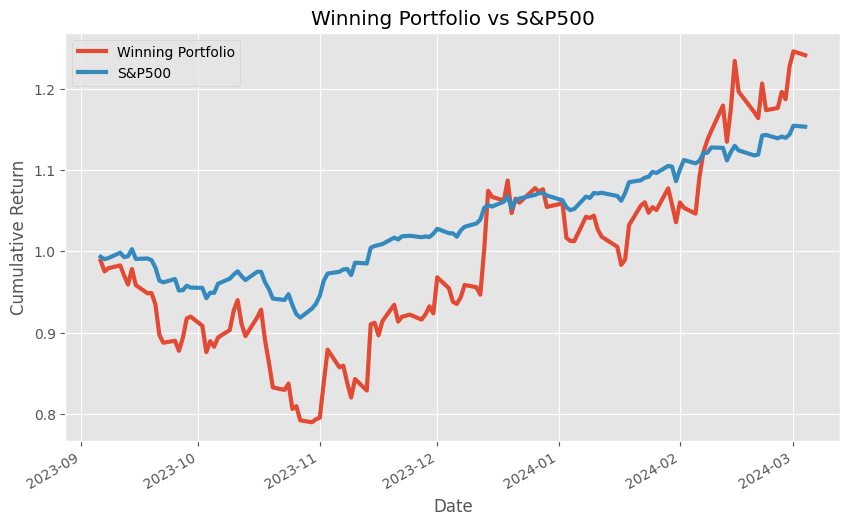

In [161]:
# plot here the return of a  winning portfolio of 10 stock and the return 
# Get the 10 best performing stocks based on PC1 weights
winning_stocks = pc1.nlargest(10).index.tolist()

# Create portfolio returns by taking mean across winning stocks
winning_portfolio = returns[winning_stocks].mean(axis=1)

# Create dataframe with winning portfolio and S&P500 returns
portfolio_df = pd.concat([winning_portfolio, prices_SPY.pct_change()], axis=1)
portfolio_df.columns = ["Winning Portfolio", "S&P500"]

# Plot cumulative returns
portfolio_df.dropna().cumsum().apply(np.exp).plot(figsize=(10,6), grid=True, linewidth=3)
plt.title('Winning Portfolio vs S&P500')
plt.ylabel('Cumulative Return')
plt.show()


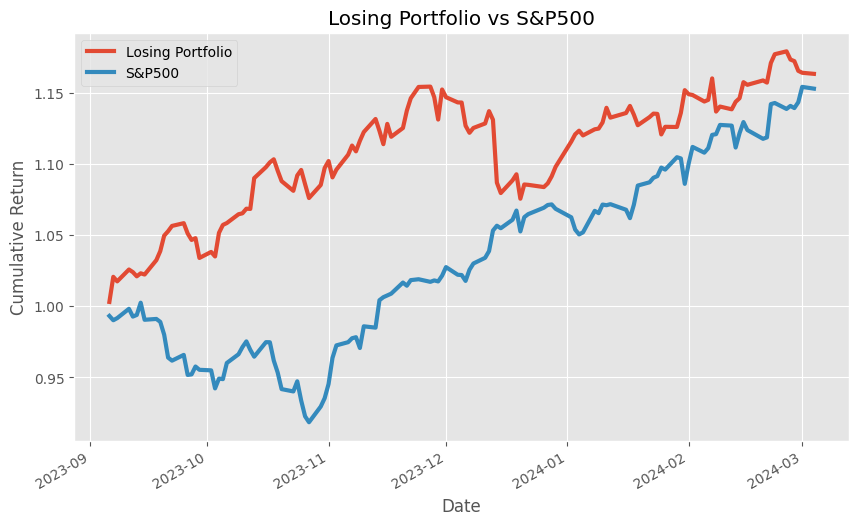

In [162]:
# plot here the return of a loosing portfolio of 10 stock and the return 
# Get the 10 worst performing stocks based on PC1 weights
losing_stocks = pc1.nsmallest(10).index.tolist()

# Create portfolio returns by taking mean across losing stocks
losing_portfolio = returns[losing_stocks].mean(axis=1)

# Create dataframe with losing portfolio and S&P500 returns
portfolio_df = pd.concat([losing_portfolio, prices_SPY.pct_change()], axis=1)
portfolio_df.columns = ["Losing Portfolio", "S&P500"]

# Plot cumulative returns
portfolio_df.dropna().cumsum().apply(np.exp).plot(figsize=(10,6), grid=True, linewidth=3)
plt.title('Losing Portfolio vs S&P500')
plt.ylabel('Cumulative Return')
plt.show()


Final questions: 

1. How could you use information provided by clustering the stocks based on the average return and volatility? You can think about portfolio allocation, trading strategies, risk management, and trends of different industries.
    
2. Repeat this exercise for different periods of time (markets goind up/down/being stable). Compare how well the first principal component PC1 tracks the S&P500 index. You will see that there is variation depending on the time period chosen. What kind of factors affect this variation? 
    
    The extent to which the first principal component PC1 tracks the index provides information about the degree of correlation between the overall movement of the index and the dominant pattern of variability captured by PC1. How could we use information in our investment decisions?


code snippets

In [163]:
#rs_df = pd.concat([myrs, prices_SPY.apply(np.log).diff(1)], axis=1)
#rs_df.columns = ["PCA Portfolio", "S&P500"]

#rs_df.dropna().cumsum().apply(np.exp).plot(subplots=True, figsize=(10,6), grid=True, linewidth=3)
#plt.show()

In [164]:
#fig, ax = plt.subplots(2,1, figsize=(10,6))
#pc1.nsmallest(10).plot.bar(ax=ax[0], color='green', grid=True, title='Stocks with Most Negative PCA Weights')
#pc1.nlargest(10).plot.bar(ax=ax[1], color='blue', grid=True, title='Stocks with Least Negative PCA Weights')

#plt.tight_layout()
#plt.savefig('tmp.png')